<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Metacritic_Games_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metacritic Games Dataset

# Introduction and Insights
---

The Metacritic Games Dataset serves as a comprehensive archive of the video game industry's history through the lens of critical reception. With approximately 14,000 entries, it acts as a bridge between professional journalism and community opinion, providing side-by-side comparisons of Metascores (aggregated critic reviews) and Userscores (player reviews) along with metadata about developers, publishers, and platforms.

One of the most compelling insights derived from our statistical analysis is the quantifiable disconnect between professional critics and everyday gamers. Through hypothesis testing, specifically a Paired T-Test, we confirmed a statistically significant difference between Metascores and Userscores, with a p-value of 0.0. This proves that these two groups fundamentally value different aspects of gaming. While there is a moderate positive correlation (approximately 0.45) between the two, it is far from a perfect reflection. Critics often prioritize technical polish, narrative innovation, and artistic merit, whereas user scores can be highly volatile—swayed by monetization practices, performance issues on specific hardware, or community-driven "review bombing." Furthermore, our normality tests revealed that neither score follows a standard bell curve. This suggests that game ratings are naturally skewed, likely clustering around favorable scores for competent games while punishing broken titles heavily, rather than following a random distribution.

Beyond the raw scores, the dataset's structure reveals the increasing complexity of the market. We discovered that fields like `platforms` and `genres` were rarely singular; games today launch across ecosystems and blend gameplay styles. To capture this, we performed feature engineering to create `platform_count` and `genre_count`. These new metrics allow us to explore whether "exclusive" titles perform better than multi-platform releases, or if focusing on a single genre yields higher praise than trying to appeal to everyone.

We also transformed the data to make it machine-readable. By extracting `release_year` and `release_month`, we moved beyond simple text strings to temporal features that can reveal seasonal trends—such as whether games released in the holiday window score higher than those dumped in the quiet winter months. Additionally, encoding the ESRB ratings and sentiment labels has turned qualitative text into quantitative signals ready for predictive modeling.

In summary, this dataset has been transformed from a raw list of reviews into a structured analytical asset. It highlights the friction between critical acclaim and player enjoyment and provides the necessary engineered features to model what truly drives a game's success in the modern era.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mohamedasak/metacritic-games-dataset

# Unziping the downloaded file
!unzip metacritic-games-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mohamedasak/metacritic-games-dataset
License(s): apache-2.0
  0% 0.00/3.90M [00:00<?, ?B/s]
100% 3.90M/3.90M [00:00<00:00, 1.56GB/s]
Archive:  metacritic-games-dataset.zip
  inflating: metacritic_games.csv    


# Data Inspection

In [3]:
df = pd.read_csv('metacritic_games.csv')
df.head(11)

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher
0,1300001620,Perfect Dark (2000),2000-05-22,M,FPS,[Xbox Live Arcade] Agent Joanna Dark hit the ...,"Nintendo 64,Xbox 360",97.0,30,Universal acclaim,84,664,Generally favorable,"97,79",Rare Ltd.,"Rare Ltd.,Xbox Game Studios,Nintendo"
1,1300027043,Grand Theft Auto IV,2008-04-29,M,Open-World Action,[Metacritic's 2008 PS3 Game of the Year; Also ...,"PlayStation 3,Xbox 360,PC",98.0,86,Universal acclaim,83,6031,Generally favorable,"98,98,90",Rockstar North,"Rockstar Games,Capcom"
2,1300003547,Tony Hawk's Pro Skater 3,2001-10-30,T,Skating,Challenge up to four friends in online competi...,"Xbox,PlayStation 2,GameCube,PlayStation,PC,Gam...",97.0,34,Universal acclaim,76,712,Generally favorable,"93,97,91,87,90,90",Neversoft Entertainment,"Activision,Success"
3,1300110124,Grand Theft Auto V,2014-11-18,M,Open-World Action,"Los Santos is a vast, sun-soaked metropolis fu...","PlayStation 3,Xbox 360,PlayStation 4,Xbox One,...",97.0,66,Universal acclaim,85,15292,Generally favorable,"97,97,97,97,96,81,79",Rockstar North,"Rockstar Games,Take-Two Interactive"
4,1300001290,The Legend of Zelda: Ocarina of Time,1998-11-23,E,Open-World Action,"As a young boy, Link is tricked by Ganondorf, ...",Nintendo 64,99.0,22,Universal acclaim,91,12158,Universal acclaim,99,Nintendo,"Nintendo,Gradiente"
5,1300001928,SoulCalibur,1999-09-08,T,3D Fighting,"[Xbox Live Arcade] Soulcalibur, the highest M...","Dreamcast,iOS (iPhone/iPad),Xbox 360",98.0,24,Universal acclaim,76,766,Generally favorable,"98,73,79",Namco,Namco
6,1300461445,Red Dead Redemption 2,2018-10-26,M,Open-World Action,Developed by the creators of Grand Theft Auto ...,"PlayStation 4,Xbox One,PC",97.0,99,Universal acclaim,89,33435,Generally favorable,"97,97,93",Rockstar Games,Rockstar Games
7,1300044129,Super Mario Galaxy 2,2010-05-23,E,3D Platformer,"Super Mario Galaxy 2, the sequel to the galaxy...",Wii,97.0,87,Universal acclaim,90,3378,Universal acclaim,97,Nintendo EAD Tokyo,"Nintendo,iQue"
8,1300019237,Super Mario Galaxy,2007-11-12,E,3D Platformer,[Metacritic's 2007 Wii Game of the Year] The u...,Wii,97.0,73,Universal acclaim,91,4866,Universal acclaim,97,Nintendo,Nintendo
9,1300108776,The Legend of Zelda: Breath of the Wild,2017-03-03,E10+,Open-World Action,Ignore everything you know about The Legend of...,"Wii U,Nintendo Switch",97.0,109,Universal acclaim,89,25809,Generally favorable,"96,97",Nintendo,Nintendo


In [5]:
df.tail(11)

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher
13902,1300315864,Alone in the Dark: Illumination,2015-06-11,NaN,Survival,A dire curse has shrouded the town of Lorwich ...,PC,19.0,12,Overwhelming dislike,13,151,Overwhelming dislike,19,Pure FPS,Atari SA
13903,1300156575,Double Dragon II: Wander of the Dragons,2013-04-05,T,2D Beat-'Em-Up,A remake the 80's Double Dragon II game. Team ...,Xbox 360,17.0,19,Overwhelming dislike,16,67,Overwhelming dislike,17,Gravity,CFK
13904,1300033568,Homie Rollerz,2008-03-05,E,Arcade Racing,"Homie Rollerz is a fast-paced, mayhem-laden ka...",DS,23.0,9,Generally unfavorable,51,13,Mixed or average,23,Webfoot Technologies,Destineer
13905,1300407810,Afro Samurai 2: Revenge of Kuma Volume One,2015-09-22,M,3D Beat-'Em-Up,"Head out on a journey of redemption, driven by...",PlayStation 4,21.0,15,Generally unfavorable,30,69,Generally unfavorable,21,Versus Evil,Versus Evil
13906,1300038501,Ride to Hell: Retribution,2013-06-25,M,Action Adventure,The game is set in the last years of the roari...,"PC,PlayStation 3,Xbox 360",19.0,14,Overwhelming dislike,13,480,Overwhelming dislike,"16,13,19",Eutechnyx,Deep Silver
13907,1300035158,SPOGS Racing,2008-07-07,E,Auto Racing,[WiiWare] Race along in distinctively unique ...,Wii,18.0,7,Overwhelming dislike,63,11,Mixed or average,18,Pronto Games,D2C Games
13908,1300028661,Deal or No Deal,2007-07-23,E,Trivia,The rules are simple. Choose a briefcase and t...,"DS,Wii",20.0,13,Generally unfavorable,38,26,Generally unfavorable,"20,56",Artefacts Studio,"Destination Software,Mindscape,Koch Media"
13909,1300033704,Yaris,2007-10-10,E10+,Auto Racing,[Xbox Live Arcade] Hop into a Toyota Yaris an...,Xbox 360,17.0,7,Overwhelming dislike,53,68,Mixed or average,17,Backbone Entertainment,Backbone Entertainment
13910,1300465525,Vroom in the Night Sky,2017-04-05,E,Biking,Vroom in the night sky is a magical bike actio...,Nintendo Switch,17.0,15,Overwhelming dislike,32,128,Generally unfavorable,17,Poisoft,Poisoft
13911,1300145643,Family Party: 30 Great Games Obstacle Arcade,2012-12-04,NaN,Party,Family Party: 30 Great Games Obstacle Arcade b...,Wii U,11.0,8,Overwhelming dislike,28,359,Generally unfavorable,11,"Art Co., Ltd.","D3Publisher,Namco Bandai Games"


In [6]:
df.shape

(13913, 16)

In [7]:
df.columns

Index(['id', 'title', 'releaseDate', 'rating', 'genres', 'description',
       'platforms', 'metascore', 'metascore_count', 'metascore_sentiment',
       'userscore', 'userscore_count', 'userscore_sentiment',
       'platform_metascores', 'developer', 'publisher'],
      dtype='object')

In [8]:
df.dtypes

,0
id,int64
title,object
releaseDate,object
rating,object
genres,object
description,object
platforms,object
metascore,float64
metascore_count,int64
metascore_sentiment,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13913 entries, 0 to 13912
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   13913 non-null  int64  
 1   title                13913 non-null  object 
 2   releaseDate          13884 non-null  object 
 3   rating               11610 non-null  object 
 4   genres               13913 non-null  object 
 5   description          13871 non-null  object 
 6   platforms            13912 non-null  object 
 7   metascore            13912 non-null  float64
 8   metascore_count      13913 non-null  int64  
 9   metascore_sentiment  13912 non-null  object 
 10  userscore            13913 non-null  int64  
 11  userscore_count      13913 non-null  int64  
 12  userscore_sentiment  12440 non-null  object 
 13  platform_metascores  13912 non-null  object 
 14  developer            13904 non-null  object 
 15  publisher            13911 non-null 

In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,13913.0,NaN,NaN,NaN,1300239472.470927,230066.968524,1300000010.0,1300025705.0,1300129384.0,1300480444.0,1300713106.0
title,13913,13913,Encore!,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
releaseDate,13884,4922,2006-11-14,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,11610,7,T,4034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,13913,119,Action Adventure,784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,13871,13795,[Xbox Live Arcade] Join your host Mr. Potato ...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platforms,13912,1320,PC,2686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metascore,13912.0,NaN,NaN,NaN,70.580865,12.28191,11.0,64.0,72.0,79.0,99.0
metascore_count,13913.0,NaN,NaN,NaN,25.920506,20.273256,4.0,11.0,19.0,34.0,150.0
metascore_sentiment,13912,5,Mixed or average,7097,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
id,0
title,0
releaseDate,29
rating,2303
genres,0
description,42
platforms,1
metascore,1
metascore_count,0
metascore_sentiment,1


# Dropping columns with more than 50% of missing data

In [12]:
df.drop(['rating','userscore_sentiment'], inplace=True, errors='ignore')

In [13]:
df.isnull().sum()

,0
id,0
title,0
releaseDate,29
rating,2303
genres,0
description,42
platforms,1
metascore,1
metascore_count,0
metascore_sentiment,1


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop(['rating', 'userscore_sentiment'], axis=1, inplace=True, errors='ignore')

In [16]:
df.isnull().sum()

,0
id,0
title,0
releaseDate,29
genres,0
description,42
platforms,1
metascore,1
metascore_count,0
metascore_sentiment,1
userscore,0


# Univariate Analysis

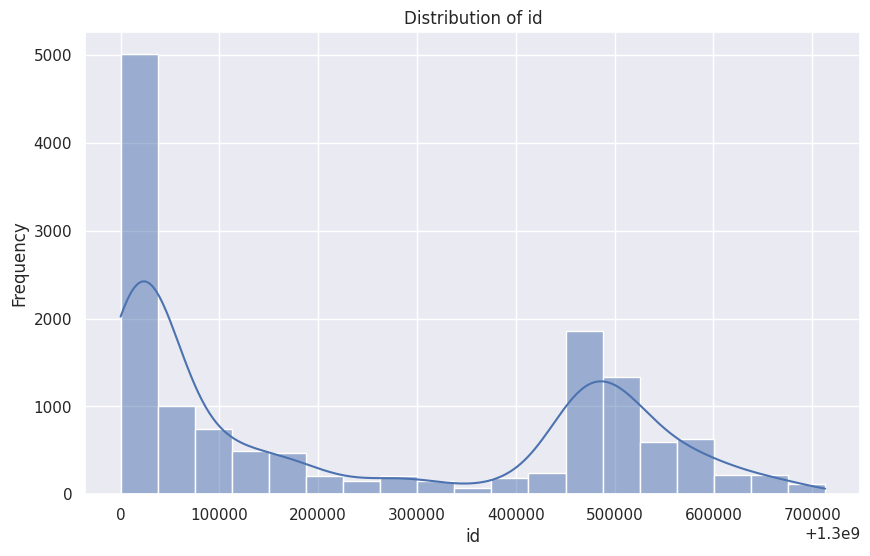

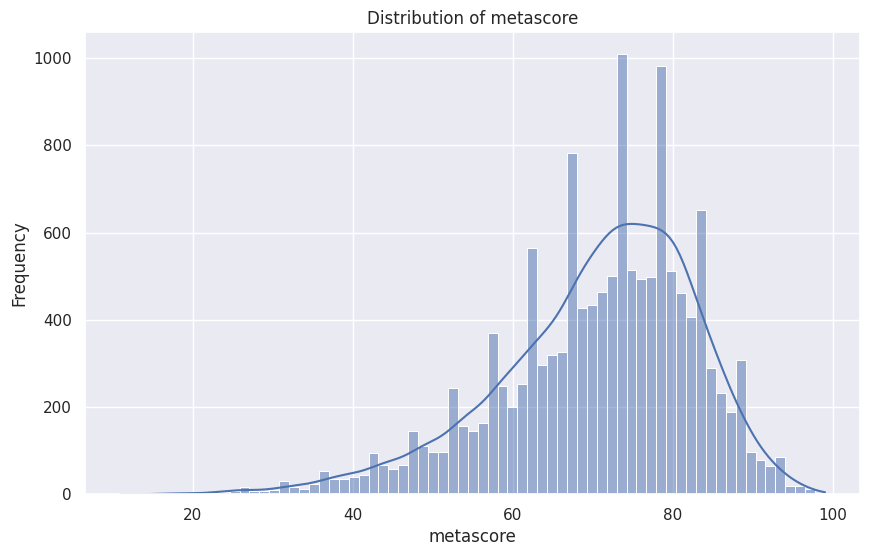

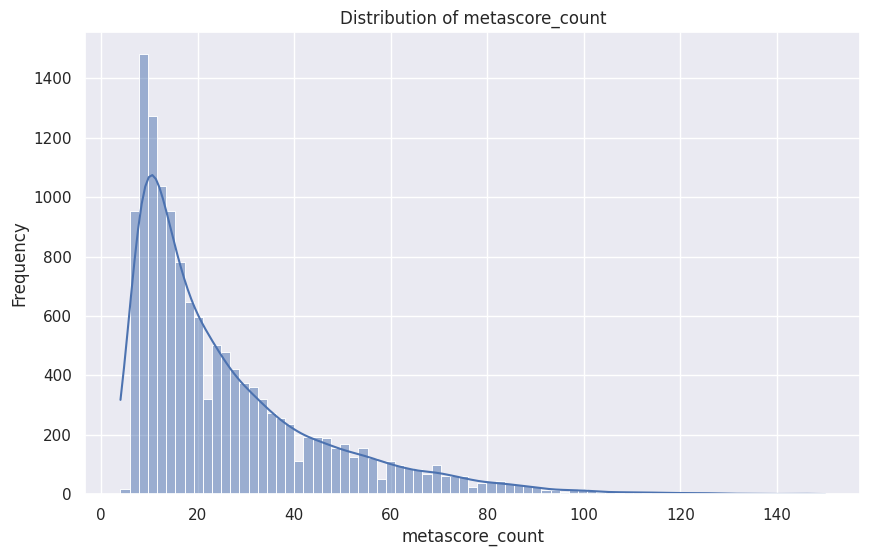

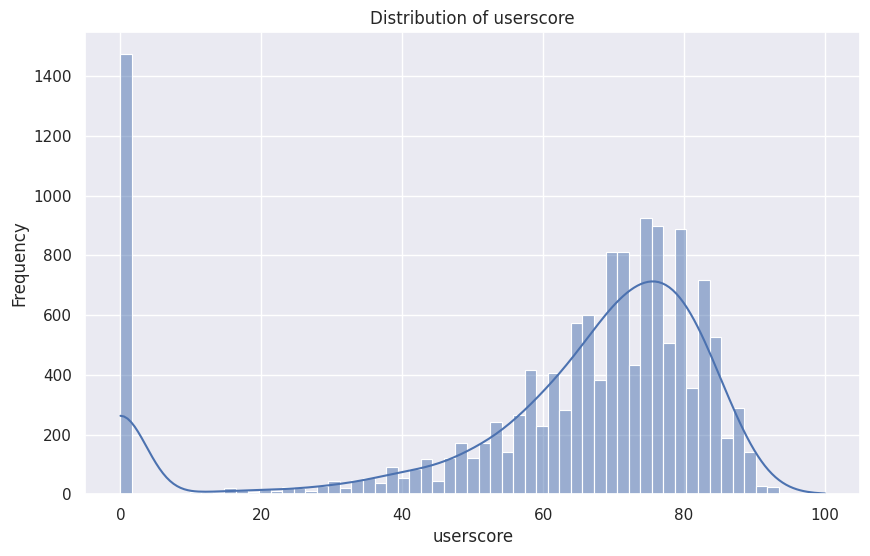

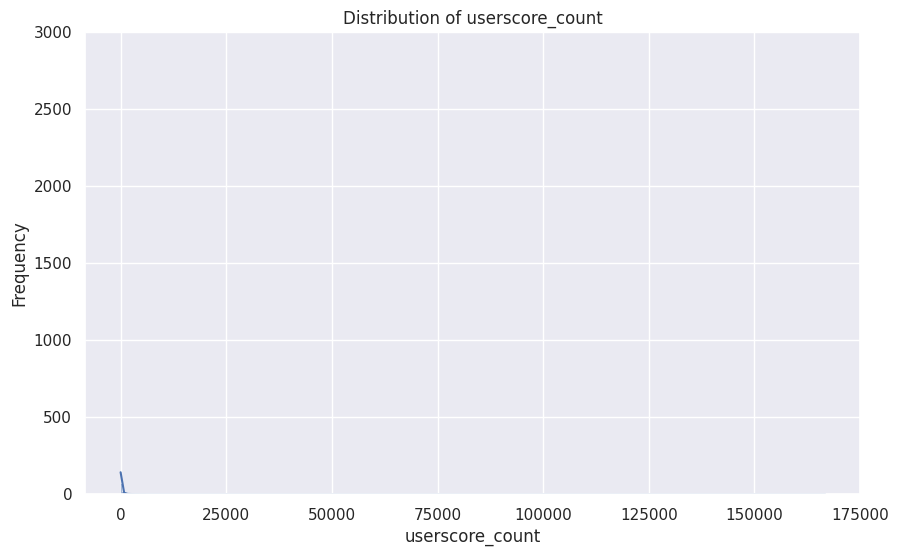

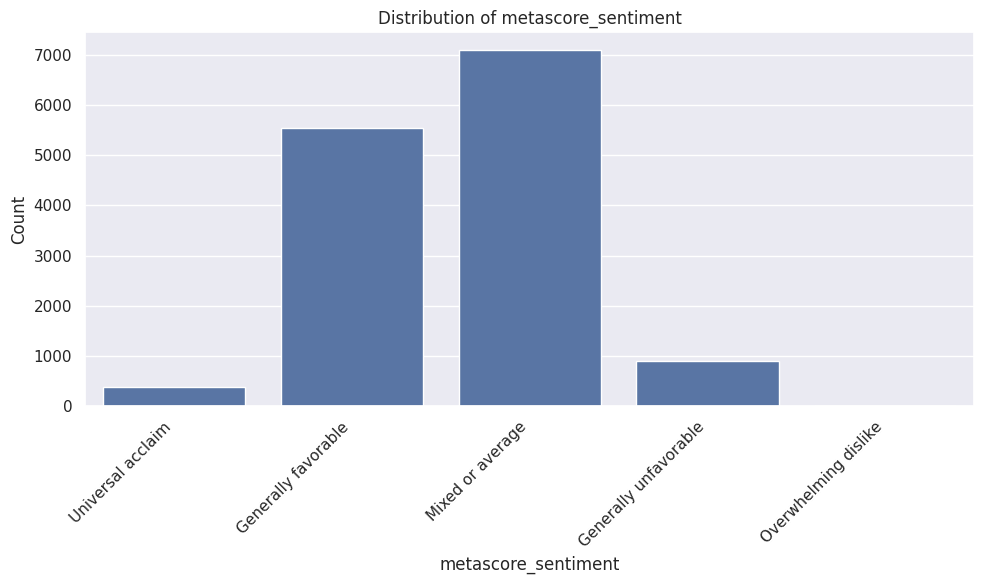

Value counts for title:
title
Encore!                                      1
Perfect Dark (2000)                          1
Grand Theft Auto IV                          1
Tony Hawk's Pro Skater 3                     1
Grand Theft Auto V                           1
                                            ..
The Elder Scrolls V: Skyrim                  1
The Legend of Zelda: Tears of the Kingdom    1
The Legend of Zelda: The Wind Waker          1
Baldur's Gate II: Shadows of Amn             1
Portal: Companion Collection                 1
Name: count, Length: 13913, dtype: int64

Value counts for releaseDate:
releaseDate
2006-11-14    29
2007-03-20    23
2012-11-18    22
2003-11-18    21
2007-10-23    21
              ..
2013-01-02     1
2014-07-09     1
2008-03-21     1
2013-05-03     1
2000-09-11     1
Name: count, Length: 4922, dtype: int64

Value counts for genres:
genres
Action Adventure    784
2D Platformer       704
Action RPG          690
FPS                 594
JRPG         

In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Columns to exclude from countplots due to high cardinality or specific content
exclude_from_countplot = [
    'id',
    'title',
    'releaseDate',
    'genres',
    'description',
    'platforms',
    'platform_metascores',
    'developer',
    'publisher'
]

# Iterate through categorical columns and create countplots for suitable columns
for col in categorical_cols:
    if col not in exclude_from_countplot:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# We can also use value_counts for a quick look at categorical data distribution
# This will still print value counts for all categorical columns, including the excluded ones
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

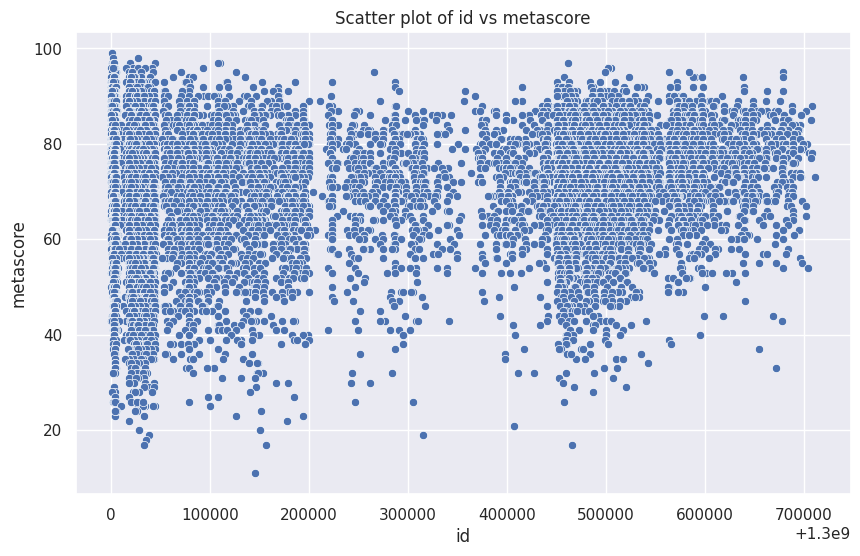

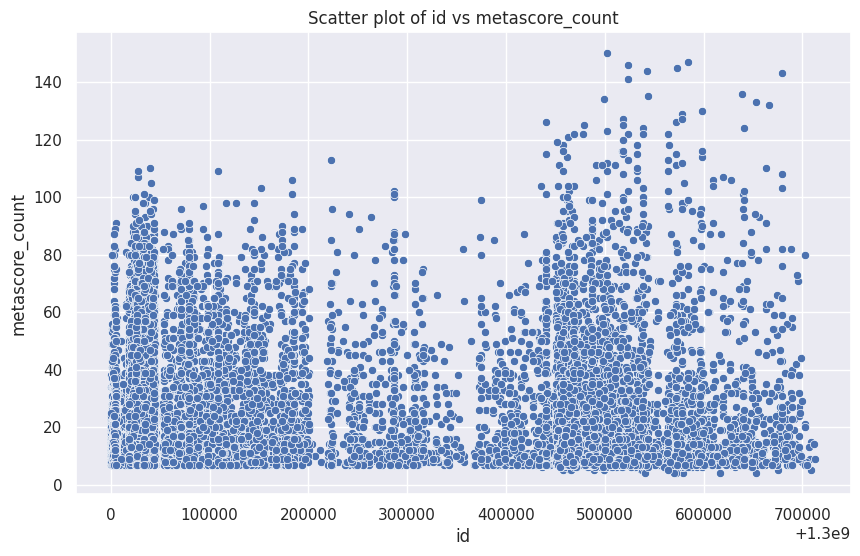

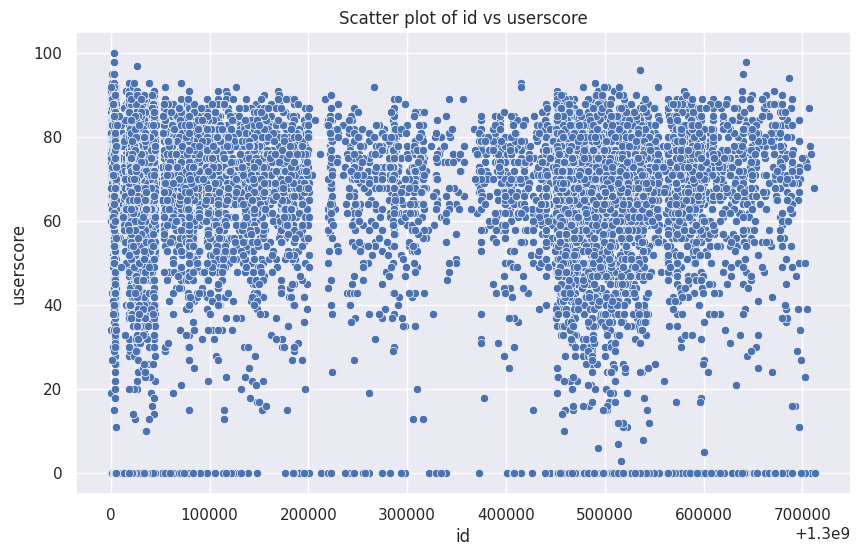

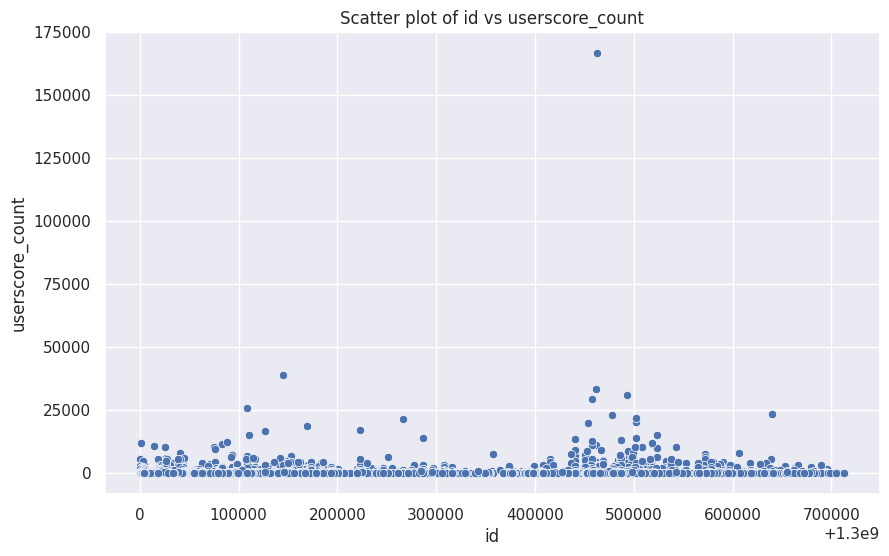

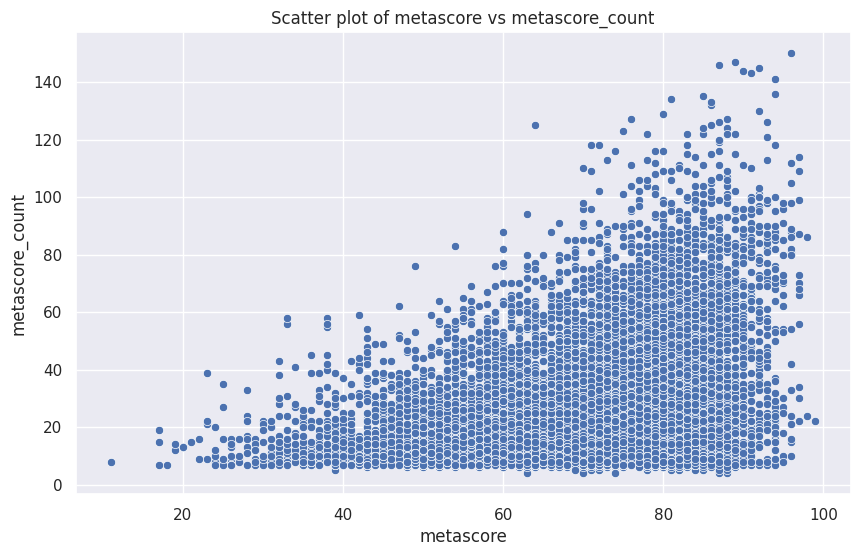

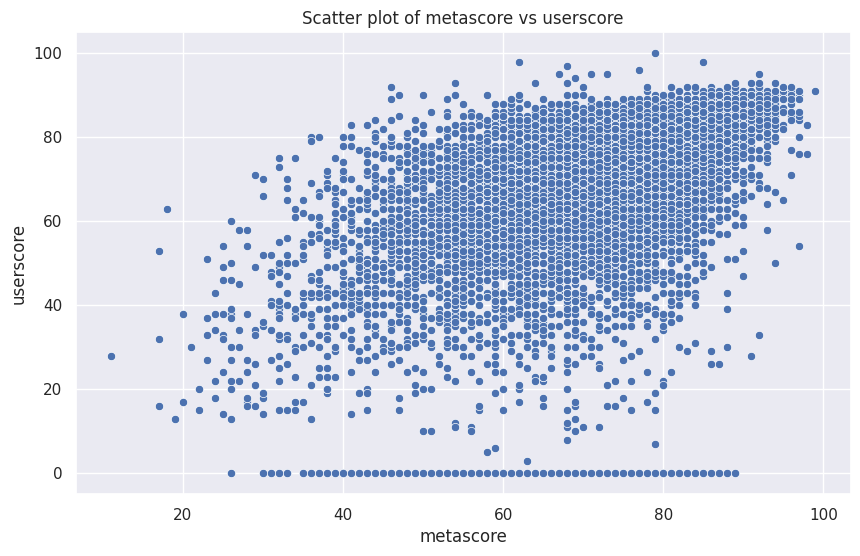

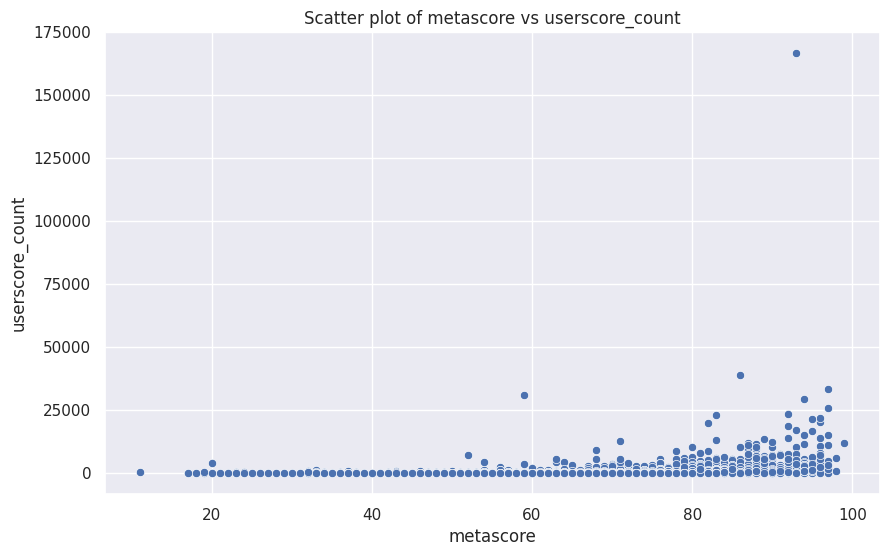

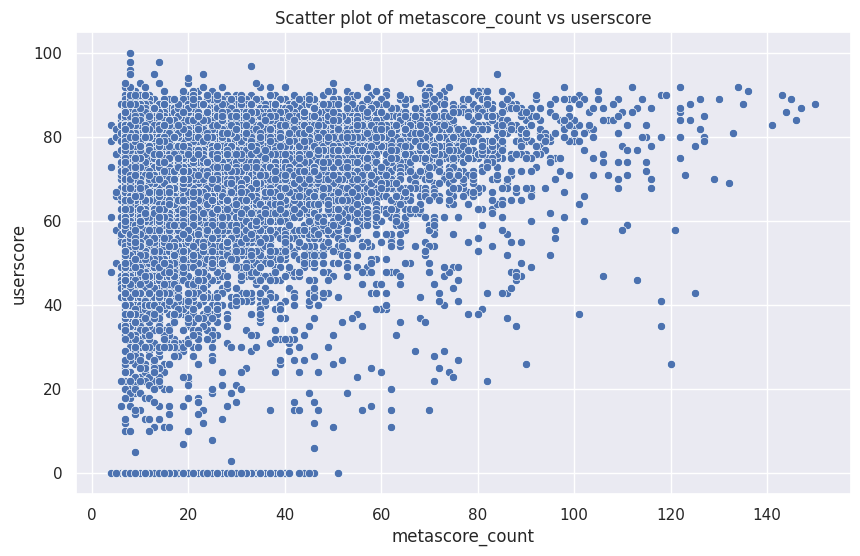

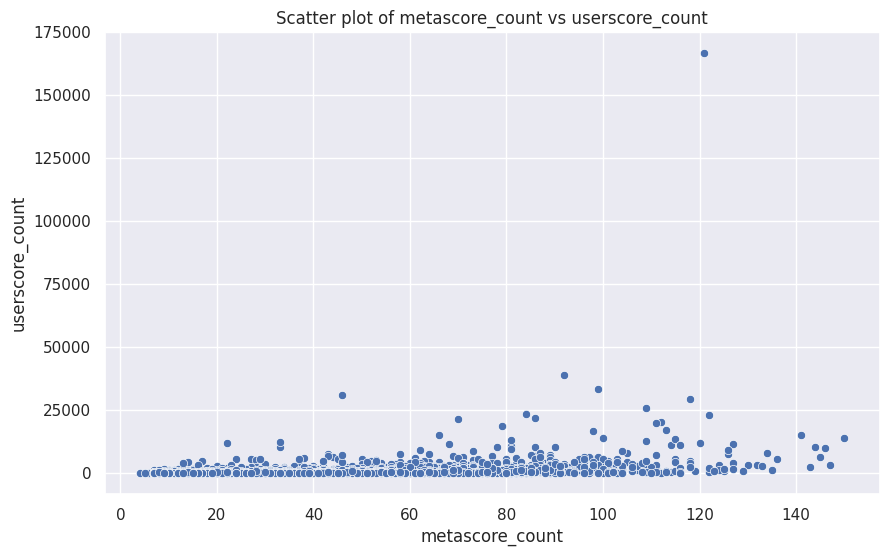

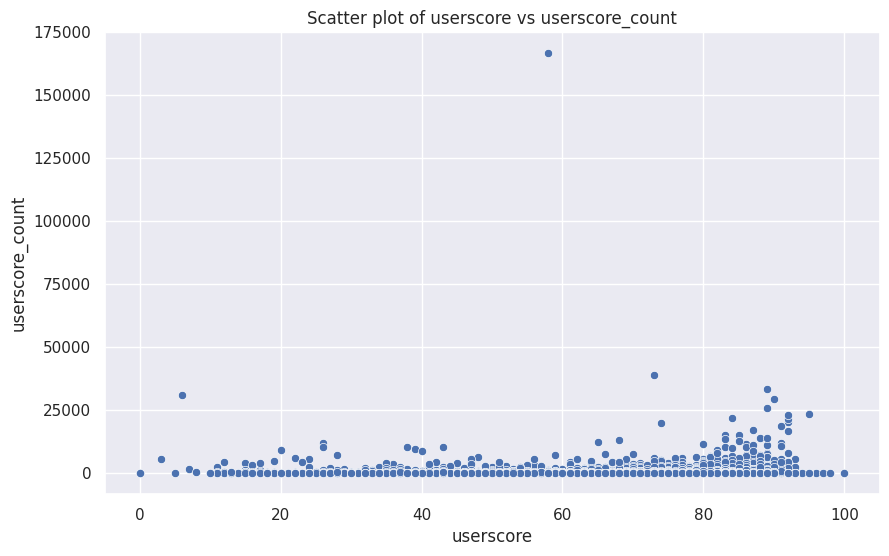

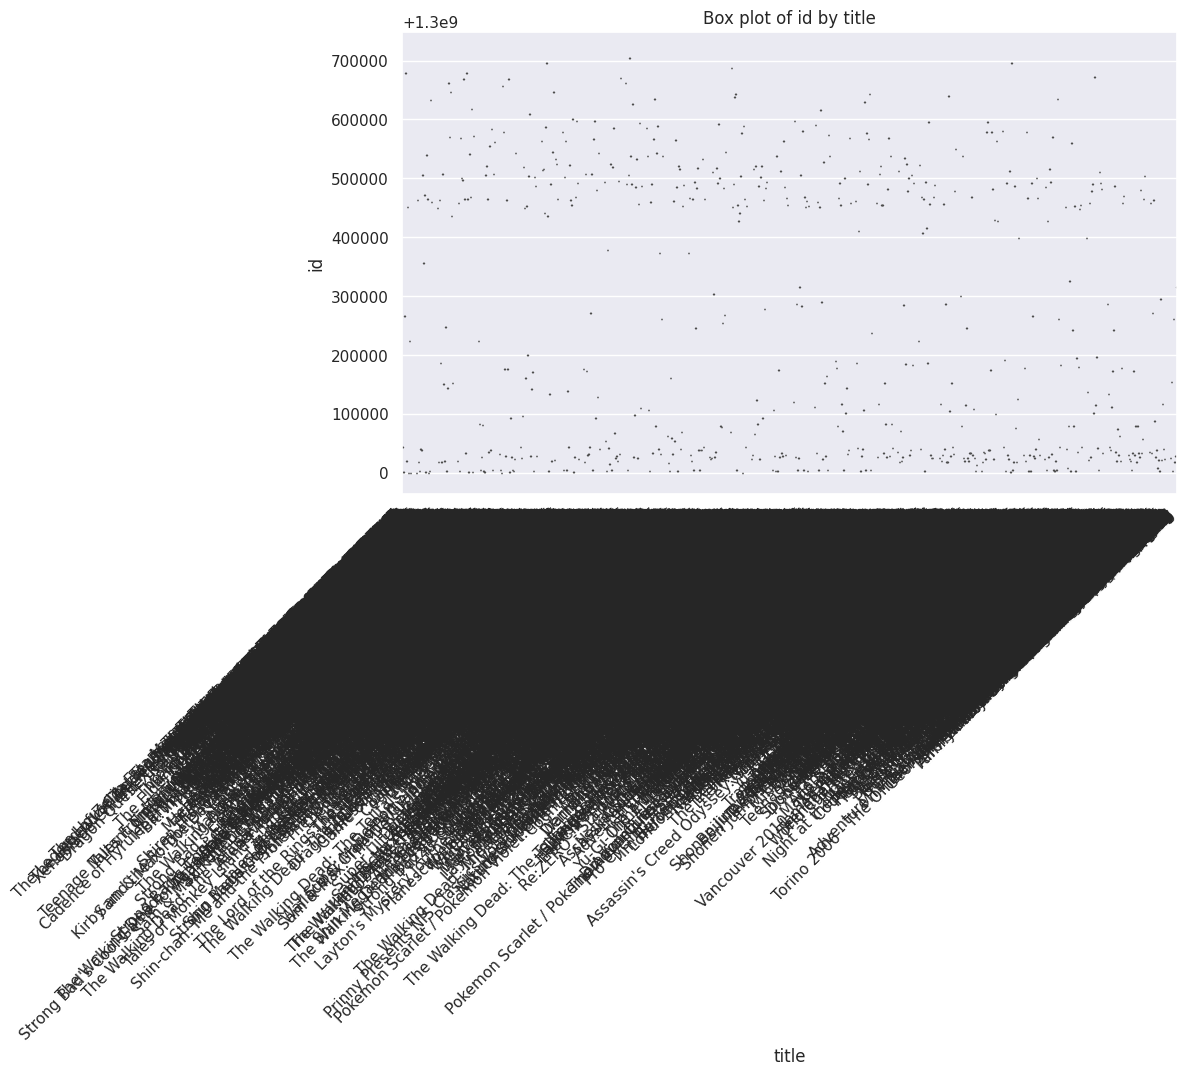

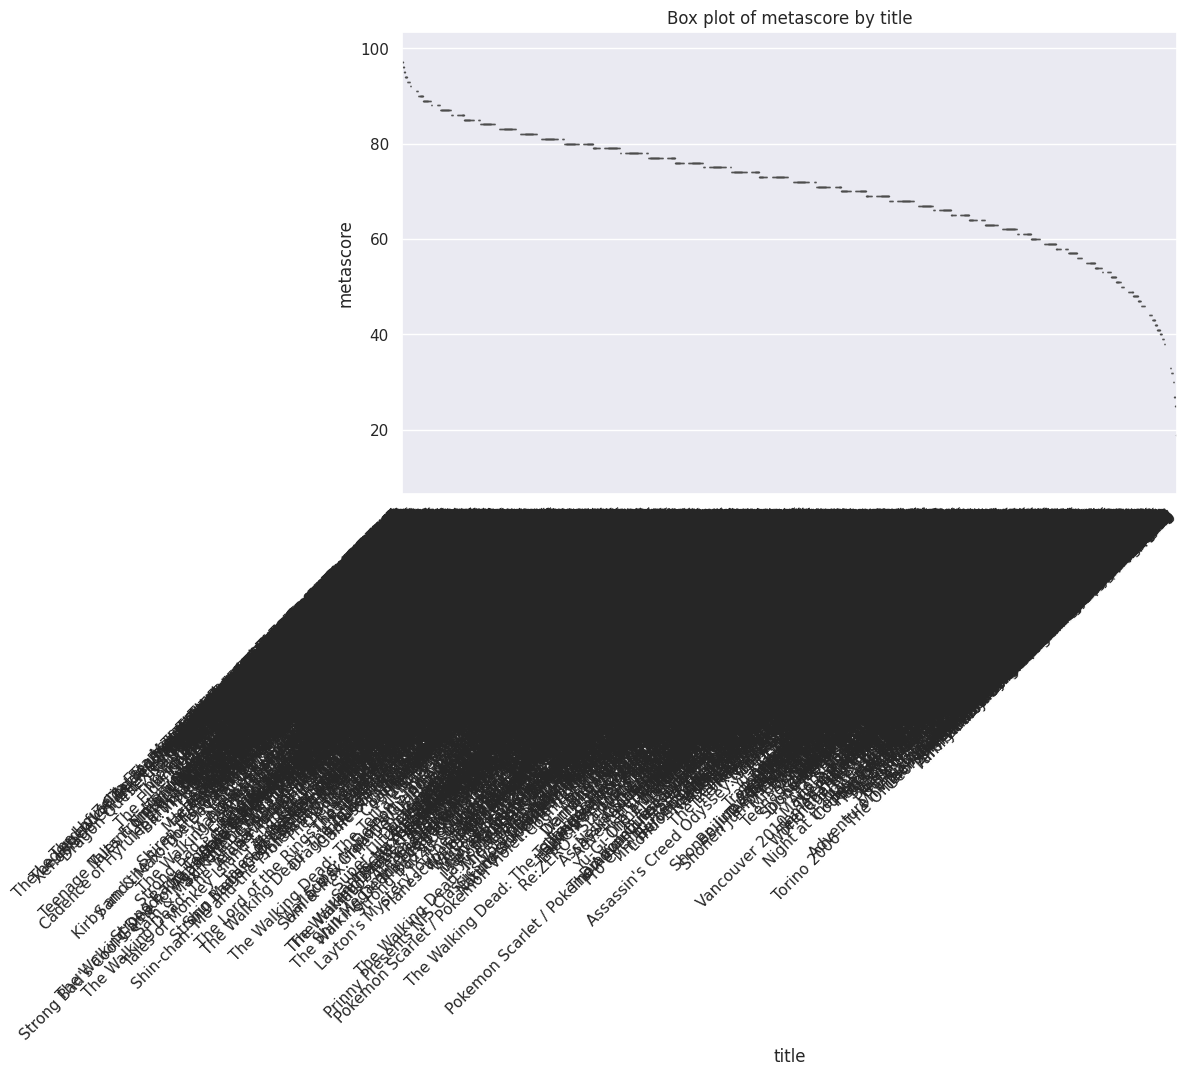

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

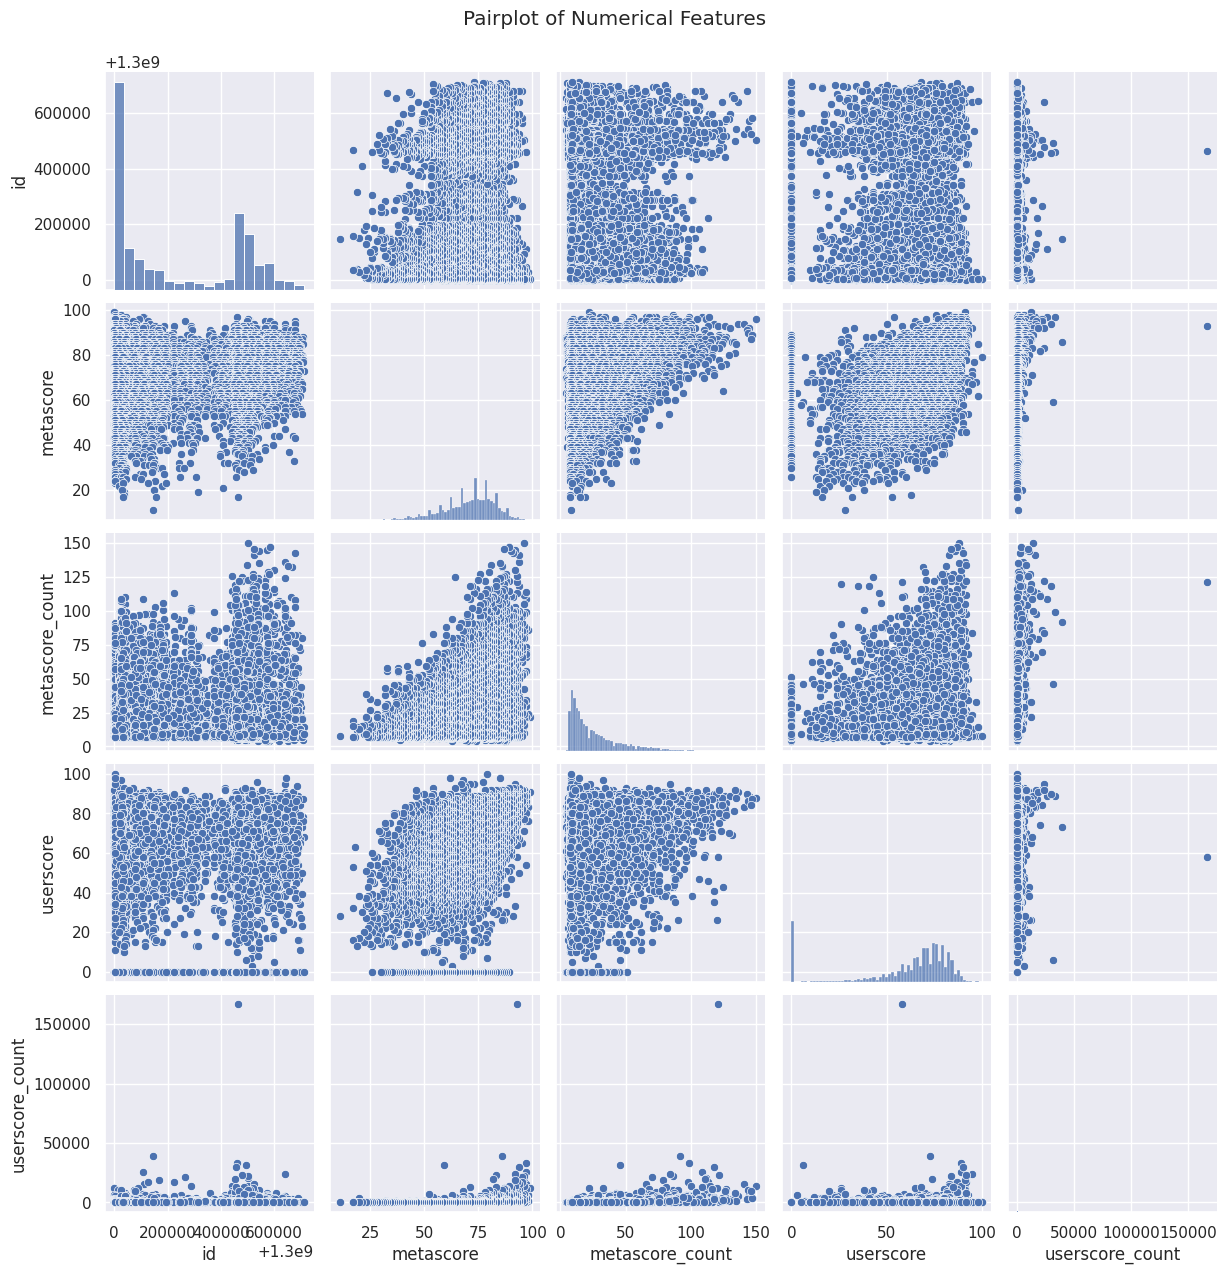

In [4]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

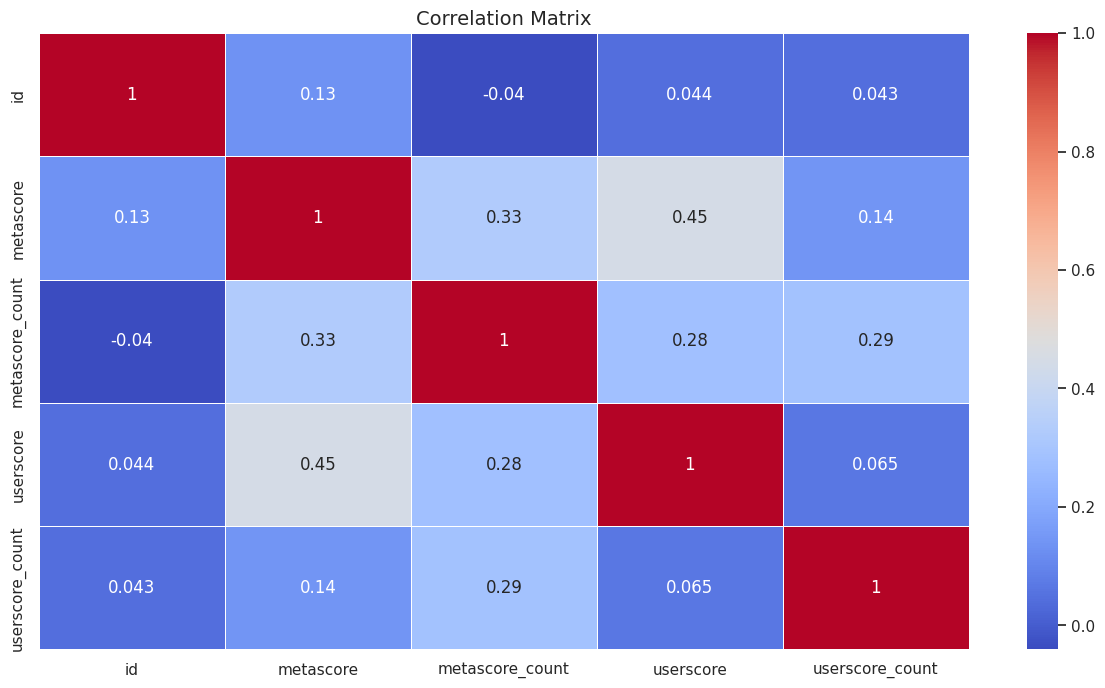

In [5]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

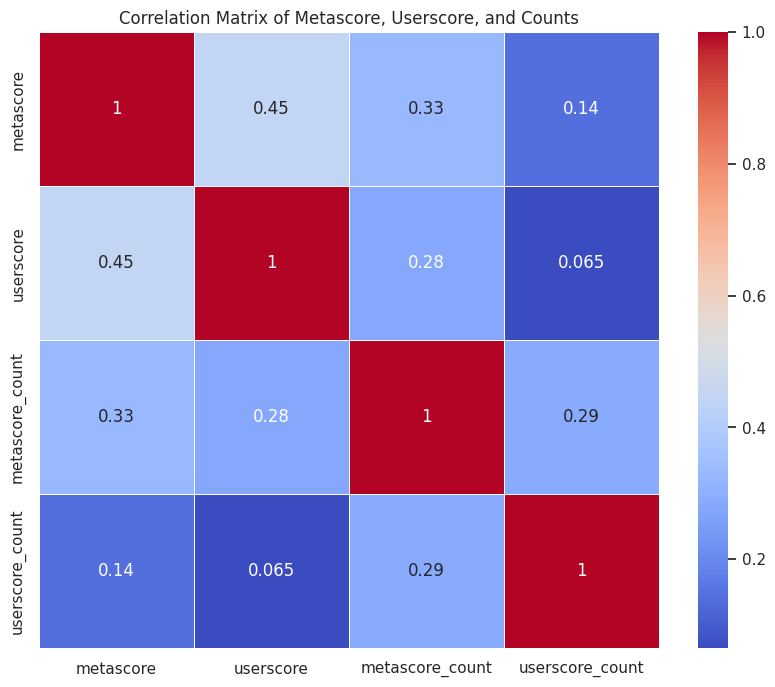

In [6]:
numerical_cols_corr = ['metascore', 'userscore', 'metascore_count', 'userscore_count']
corr_matrix = df[numerical_cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Metascore, Userscore, and Counts')
plt.show()

## Hypothesis Testing (Critics vs. Users)


In [7]:
from scipy import stats

# Dropping rows with missing values in 'metascore' or 'userscore'
df_clean = df.dropna(subset=['metascore', 'userscore'])

# Conducting Paired T-Test
t_stat, p_val = stats.ttest_rel(df_clean['metascore'], df_clean['userscore'])

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 46.31023800463632
P-value: 0.0


## Normality Test


In [8]:
from scipy.stats import normaltest

# Perform D'Agostino's K^2 test for Metascore
stat_meta, p_meta = normaltest(df_clean['metascore'])
print(f"Metascore Normality Test:\nStatistic: {stat_meta:.4f}, P-value: {p_meta}")

if p_meta < 0.05:
    print("Interpretation: The distribution of Metascore is significantly different from a normal distribution (Reject H0).")
else:
    print("Interpretation: The distribution of Metascore is not significantly different from a normal distribution (Fail to reject H0).")

print("\n" + "-"*50 + "\n")

# Perform D'Agostino's K^2 test for Userscore
stat_user, p_user = normaltest(df_clean['userscore'])
print(f"Userscore Normality Test:\nStatistic: {stat_user:.4f}, P-value: {p_user}")

if p_user < 0.05:
    print("Interpretation: The distribution of Userscore is significantly different from a normal distribution (Reject H0).")
else:
    print("Interpretation: The distribution of Userscore is not significantly different from a normal distribution (Fail to reject H0).")

Metascore Normality Test:
Statistic: 1356.0712, P-value: 3.4110105580704674e-295
Interpretation: The distribution of Metascore is significantly different from a normal distribution (Reject H0).

--------------------------------------------------

Userscore Normality Test:
Statistic: 3503.8503, P-value: 0.0
Interpretation: The distribution of Userscore is significantly different from a normal distribution (Reject H0).


# Feature Engineering



## Date Feature Extraction


In [9]:
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')
df['release_year'] = df['releaseDate'].dt.year
df['release_month'] = df['releaseDate'].dt.month

df.head()

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher,release_year,release_month
0,1300001620,Perfect Dark (2000),2000-05-22,M,FPS,[Xbox Live Arcade] Agent Joanna Dark hit the ...,"Nintendo 64,Xbox 360",97.0,30,Universal acclaim,84,664,Generally favorable,"97,79",Rare Ltd.,"Rare Ltd.,Xbox Game Studios,Nintendo",2000.0,5.0
1,1300027043,Grand Theft Auto IV,2008-04-29,M,Open-World Action,[Metacritic's 2008 PS3 Game of the Year; Also ...,"PlayStation 3,Xbox 360,PC",98.0,86,Universal acclaim,83,6031,Generally favorable,"98,98,90",Rockstar North,"Rockstar Games,Capcom",2008.0,4.0
2,1300003547,Tony Hawk's Pro Skater 3,2001-10-30,T,Skating,Challenge up to four friends in online competi...,"Xbox,PlayStation 2,GameCube,PlayStation,PC,Gam...",97.0,34,Universal acclaim,76,712,Generally favorable,"93,97,91,87,90,90",Neversoft Entertainment,"Activision,Success",2001.0,10.0
3,1300110124,Grand Theft Auto V,2014-11-18,M,Open-World Action,"Los Santos is a vast, sun-soaked metropolis fu...","PlayStation 3,Xbox 360,PlayStation 4,Xbox One,...",97.0,66,Universal acclaim,85,15292,Generally favorable,"97,97,97,97,96,81,79",Rockstar North,"Rockstar Games,Take-Two Interactive",2014.0,11.0
4,1300001290,The Legend of Zelda: Ocarina of Time,1998-11-23,E,Open-World Action,"As a young boy, Link is tricked by Ganondorf, ...",Nintendo 64,99.0,22,Universal acclaim,91,12158,Universal acclaim,99,Nintendo,"Nintendo,Gradiente",1998.0,11.0


## List Column Feature Engineering



In [10]:
df['platform_count'] = df['platforms'].str.split(',').str.len()
df['genre_count'] = df['genres'].str.split(',').str.len()

df.head()

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher,release_year,release_month,platform_count,genre_count
0,1300001620,Perfect Dark (2000),2000-05-22,M,FPS,[Xbox Live Arcade] Agent Joanna Dark hit the ...,"Nintendo 64,Xbox 360",97.0,30,Universal acclaim,84,664,Generally favorable,"97,79",Rare Ltd.,"Rare Ltd.,Xbox Game Studios,Nintendo",2000.0,5.0,2.0,1
1,1300027043,Grand Theft Auto IV,2008-04-29,M,Open-World Action,[Metacritic's 2008 PS3 Game of the Year; Also ...,"PlayStation 3,Xbox 360,PC",98.0,86,Universal acclaim,83,6031,Generally favorable,"98,98,90",Rockstar North,"Rockstar Games,Capcom",2008.0,4.0,3.0,1
2,1300003547,Tony Hawk's Pro Skater 3,2001-10-30,T,Skating,Challenge up to four friends in online competi...,"Xbox,PlayStation 2,GameCube,PlayStation,PC,Gam...",97.0,34,Universal acclaim,76,712,Generally favorable,"93,97,91,87,90,90",Neversoft Entertainment,"Activision,Success",2001.0,10.0,6.0,1
3,1300110124,Grand Theft Auto V,2014-11-18,M,Open-World Action,"Los Santos is a vast, sun-soaked metropolis fu...","PlayStation 3,Xbox 360,PlayStation 4,Xbox One,...",97.0,66,Universal acclaim,85,15292,Generally favorable,"97,97,97,97,96,81,79",Rockstar North,"Rockstar Games,Take-Two Interactive",2014.0,11.0,7.0,1
4,1300001290,The Legend of Zelda: Ocarina of Time,1998-11-23,E,Open-World Action,"As a young boy, Link is tricked by Ganondorf, ...",Nintendo 64,99.0,22,Universal acclaim,91,12158,Universal acclaim,99,Nintendo,"Nintendo,Gradiente",1998.0,11.0,1.0,1


## Categorical Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Fill missing values in 'rating'
df['rating'] = df['rating'].fillna('Unknown')

# 2 & 3. Label Encoding for 'rating'
le = LabelEncoder()
df['rating'] = le.fit_transform(df['rating'])

# 4. One-Hot Encoding for 'metascore_sentiment'
df = pd.get_dummies(df, columns=['metascore_sentiment'], prefix='sentiment')

# 5. Display first 5 rows
df.head()

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,userscore,...,publisher,release_year,release_month,platform_count,genre_count,sentiment_Generally favorable,sentiment_Generally unfavorable,sentiment_Mixed or average,sentiment_Overwhelming dislike,sentiment_Universal acclaim
0,1300001620,Perfect Dark (2000),2000-05-22,4,FPS,[Xbox Live Arcade] Agent Joanna Dark hit the ...,"Nintendo 64,Xbox 360",97.0,30,84,...,"Rare Ltd.,Xbox Game Studios,Nintendo",2000.0,5.0,2.0,1,False,False,False,False,True
1,1300027043,Grand Theft Auto IV,2008-04-29,4,Open-World Action,[Metacritic's 2008 PS3 Game of the Year; Also ...,"PlayStation 3,Xbox 360,PC",98.0,86,83,...,"Rockstar Games,Capcom",2008.0,4.0,3.0,1,False,False,False,False,True
2,1300003547,Tony Hawk's Pro Skater 3,2001-10-30,6,Skating,Challenge up to four friends in online competi...,"Xbox,PlayStation 2,GameCube,PlayStation,PC,Gam...",97.0,34,76,...,"Activision,Success",2001.0,10.0,6.0,1,False,False,False,False,True
3,1300110124,Grand Theft Auto V,2014-11-18,4,Open-World Action,"Los Santos is a vast, sun-soaked metropolis fu...","PlayStation 3,Xbox 360,PlayStation 4,Xbox One,...",97.0,66,85,...,"Rockstar Games,Take-Two Interactive",2014.0,11.0,7.0,1,False,False,False,False,True
4,1300001290,The Legend of Zelda: Ocarina of Time,1998-11-23,1,Open-World Action,"As a young boy, Link is tricked by Ganondorf, ...",Nintendo 64,99.0,22,91,...,"Nintendo,Gradiente",1998.0,11.0,1.0,1,False,False,False,False,True


# Thank You